# RL Exercise Demo
This exercise serves as a demonstration how to quickly train an RL agent on a popular environment with a RL framework.
We will
1. Select and instantiate environment (gym's BipedalWalker-v3).
2. Select and setup our RL algorithm / agent (stablebaselines3 [SAC](https://spinningup.openai.com/en/latest/algorithms/sac.html)).
3. Train the agent on the environment and visualize training progress.
4. Evaluate our agent and observe the distribution of test performances.
5. Record and replay the agent, before and after.

## The Environment: Bipedal Walker
![Bipedal Walker](bipedal_walker.gif) [credits](https://www.gymlibrary.dev/_images/bipedal_walker.gif)

![Interaction Env-Agent](env_agent.png)

### Env
- locomotion
- 4 joints

### Action Space
- motor speed for all 4 joints (hips and knees) [-1, 1]

### Observation Space
State consists of
- hull angle speed
- angular velocity
- horizontal speed
- vertical speed
- position of joints
- joints angular speed
- legs contact with ground
- 10 lidar rangefinder measurements

There are no coordinates! State vector with 24 entries.

### Rewards
Moving forward gives rewards.
Falling is punished.
Applying motor torque costs a little.


### Starting State
Stands at the left in a certain position.

### Episode Termination
- walker falls
- or reaches end of terrain


In [1]:
import pandas as pd

model_fn = "trained_agent.zip"
env_id = "BipedalWalker-v3"
log_dir = "logs/tensorboard"

## The Agent: SAC
SAC: Soft Actor Critic
[[paper]](https://arxiv.org/abs/1801.01290) [[blogpost]](https://spinningup.openai.com/en/latest/algorithms/sac.html)

- off-policy algorithm
- for continuous actions
- one actor, one critic
- special regularization to steer exploration-exploitation trade-off 

In [ ]:
import gymnasium as gym
from stable_baselines3 import SAC

env = gym.make(env_id)
model = SAC("MlpPolicy", env, verbose=1, tensorboard_log=log_dir)
model.learn(total_timesteps=500_000)
model.save(model_fn)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to logs/tensorboard/SAC_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 456      |
|    ep_rew_mean     | -104     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 148      |
|    time_elapsed    | 12       |
|    total_timesteps | 1822     |
| train/             |          |
|    actor_loss      | -16.9    |
|    critic_loss     | 40.8     |
|    ent_coef        | 0.597    |
|    ent_coef_loss   | -3.41    |
|    learning_rate   | 0.0003   |
|    n_updates       | 1721     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 645      |
|    ep_rew_mean     | -95.6    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 168      |
|    time_elapsed    | 30       |
|    total_timesteps |

# Rollout

### Evaluate Trained and Random Agent
Here we roll out the agents with logging for multiple random seeds. 

In [4]:
import gymnasium as gym
import numpy as np
from gymnasium.wrappers import RecordEpisodeStatistics
from stable_baselines3 import SAC

n_eval_episodes = 10
eval_seeds = [
    30,
    40,
    50,
]  # Evaluate across multiple seeds

# Untrained agent
env_standard = gym.make(env_id)
untrained_agent = SAC("MlpPolicy", env_standard, verbose=0)

# Trained agent
trained_agent = SAC.load(model_fn)

agents = {
    "Untrained SAC": untrained_agent,
    "Trained SAC": trained_agent,
}


# Create a function to evaluate an SB3 agent using gym structures over multiple seeds
def evaluate_agent(model, env_id, n_episodes, seeds):
    env = gym.make(env_id)
    env = RecordEpisodeStatistics(env)  # Attach the Gym Logger

    all_results = []

    for seed in seeds:
        returns = []
        lengths = []
        # Seed the environment's action space and initial state
        env.action_space.seed(seed)

        for ep in range(n_episodes):
            obs, info = env.reset(seed=seed + ep)
            done = False
            while not done:
                # SB3 predict
                action, _states = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                # Use RecordEpisodeStatistics data immediately
                if done:
                    returns.append(info["episode"]["r"])
                    lengths.append(info["episode"]["l"])

        all_results.append({"seed": seed, "returns": returns, "lengths": lengths})

    env.close()
    return all_results


results = []
for name, agent_model in agents.items():
    # Evaluate policy
    seed_results = evaluate_agent(agent_model, env_id, n_eval_episodes, eval_seeds)

    # Calculate performance for printing
    all_returns = [np.mean(res["returns"]) for res in seed_results]
    performance = np.mean(all_returns)
    print(f"Agent: {name} | Mean Return (over seeds): {performance:.2f}")

    for res in seed_results:
        results.append(
            pd.DataFrame(
                {
                    "agent": name,
                    "seed": res["seed"],
                    "episode": np.arange(0, n_eval_episodes),
                    "reward": res["returns"],
                    "length": res["lengths"],
                }
            )
        )

results = pd.concat(results).reset_index(drop=True)

/home/mingxuan/Repos/RL-exercise-fork/.venv/lib/python3.11/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Agent: Untrained SAC | Mean Return (over seeds): -100.64
Agent: Trained SAC | Mean Return (over seeds): 306.49


Plotting the results

agent  seed  episode      reward  length
0   Untrained SAC    30        0 -100.429619     137
1   Untrained SAC    30        1 -100.789734     165
2   Untrained SAC    30        2 -100.633492     153
3   Untrained SAC    30        3 -100.673180     171
4   Untrained SAC    30        4 -100.642357     162
5   Untrained SAC    30        5 -100.625809     156
6   Untrained SAC    30        6 -100.879669     194
7   Untrained SAC    30        7 -100.754662     177
8   Untrained SAC    30        8 -100.424316     137
9   Untrained SAC    30        9 -100.529579     149
10  Untrained SAC    40        0 -100.813210     182
11  Untrained SAC    40        1 -100.900246     194
12  Untrained SAC    40        2 -100.459885     138
13  Untrained SAC    40        3 -100.631561     155
14  Untrained SAC    40        4 -100.641693     163
15  Untrained SAC    40        5 -100.619736     153
16  Untrained SAC    40        6 -100.447617     137
17  Untrained SAC    40        7 -100.601372     154
18  Untrained SAC    40        8 -100.759148     174
19  Untrained SAC    40        9 -100.561913     158
20  Untrained SAC    50        0 -100.519394     147
21  Untrained SAC    50        1 -100.679680     166
22  Untrained SAC    50        2 -100.456772     144
23  Untrained SAC    50        3 -100.430550     140
24  Untrained SAC    50        4 -100.884163     201
25  Untrained SAC    50        5 -101.004669     201
26  Untrained SAC    50        6 -100.665878     165
27  Untrained SAC    50        7 -100.615501     165
28  Untrained SAC    50        8 -100.565781     148
29  Untrained SAC    50        9 -100.642570     164
30    Trained SAC    30        0  310.724243     832
31    Trained SAC    30        1  311.193481     827
32    Trained SAC    30        2  311.005829     822
33    Trained SAC    30        3  310.299072     830
34    Trained SAC    30        4  309.959869     841
35    Trained SAC    30        5  310.649139     822
36    Trained SAC    30        6  192.273804     816
37    Trained SAC    30        7  310.906281     834
38    Trained SAC    30        8  311.126282     832
39    Trained SAC    30        9  310.180481     830
40    Trained SAC    40        0  310.423401     827
41    Trained SAC    40        1  310.254028     849
42    Trained SAC    40        2  310.513611     819
43    Trained SAC    40        3  309.778809     844
44    Trained SAC    40        4  310.578308     853
45    Trained SAC    40        5  310.354614     830
46    Trained SAC    40        6  310.520813     827
47    Trained SAC    40        7  309.758331     852
48    Trained SAC    40        8  309.458282     840
49    Trained SAC    40        9  310.553986     846
50    Trained SAC    50        0  310.115265     817
51    Trained SAC    50        1  309.755157     839
52    Trained SAC    50        2  311.078308     818
53    Trained SAC    50        3  310.400177     839
54    Trained SAC    50        4  310.902191     837
55    Trained SAC    50        5  310.126709     841
56    Trained SAC    50        6  310.369690     845
57    Trained SAC    50        7  310.229340     844
58    Trained SAC    50        8  311.030579     818
59    Trained SAC    50        9  310.147369     831

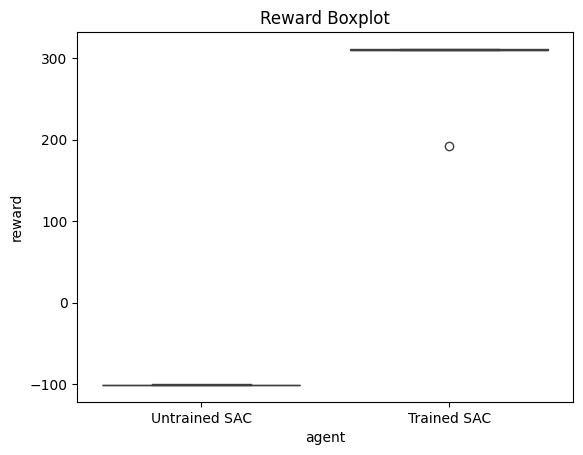

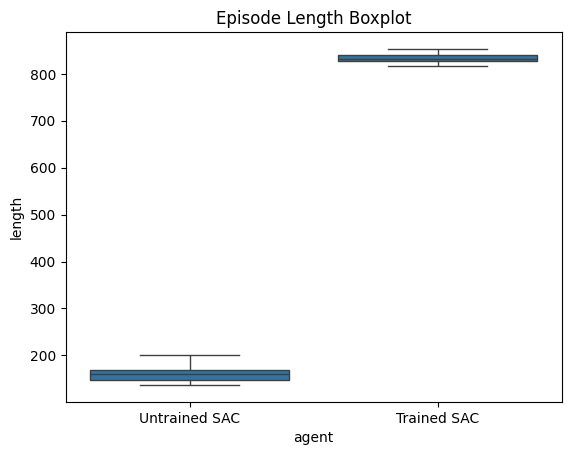

In [9]:
from rich import print as printr
import seaborn as sns
import matplotlib.pyplot as plt

df = results
printr(df)

# You can use boxplots to show aggregate evaluations across all seeds
ax = sns.boxplot(data=df, x="agent", y="reward")
plt.title("Reward Boxplot")
plt.show()

sns.boxplot(data=df, x="agent", y="length")
plt.title("Episode Length Boxplot")
plt.show()

In [10]:
video_folder = "logs/videos/"
video_length = 1000

## Record random agent
The recorded videos are saved at `logs/videos`

In [11]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

# Create environment with rgb_array render mode indicating we want frame outputs
env = gym.make(env_id, render_mode="rgb_array")

# Native Gymnasium Video Recorder Wrapper - fully replaces VecVideoRecorder
env = RecordVideo(
    env,
    video_folder=video_folder,
    episode_trigger=lambda x: x == 0,  # Record the first episode
    name_prefix=f"random-agent-{env_id}",
)

obs, info = env.reset()

for i in range(video_length):
    # Evaluate the random (untrained) agent using the SB3 model
    action, _ = untrained_agent.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break

env.close()

## Record trained agent

In [12]:
from gymnasium.wrappers import RecordVideo
import gymnasium as gym

env = gym.make(env_id, render_mode="rgb_array")

# Record the video using native gym wrappers!
env = RecordVideo(
    env,
    video_folder=video_folder,
    episode_trigger=lambda x: x == 0,
    name_prefix=f"trained-agent-{env_id}",
)

obs, info = env.reset()

for i in range(video_length):
    # Now PREDICT the action to take with our trained SB3 model 🤖
    action, _ = trained_agent.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break

env.close()

/home/mingxuan/Repos/RL-exercise-fork/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/mingxuan/Repos/RL-exercise-fork/rl_exercises/week_1/logs/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
